# Demo Code

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
I successfully loaded the trained model.
I identified the following classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

I started the live demonstration using selected MRI images.

Input Image 1
I selected an MRI image from the testing dataset.
Ground Truth Label: glioma
Image Shape: (512, 512, 3)
Pixel Value Range: 0.0 to 1.0


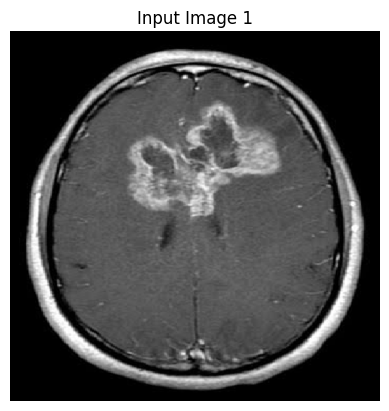

Output for Image 1
I analyzed prediction probabilities for all classes:
glioma : 1.0000
pituitary : 0.0000
notumor : 0.0000
meningioma : 0.0000
Final Predicted Class: glioma
Prediction Confidence: 1.0


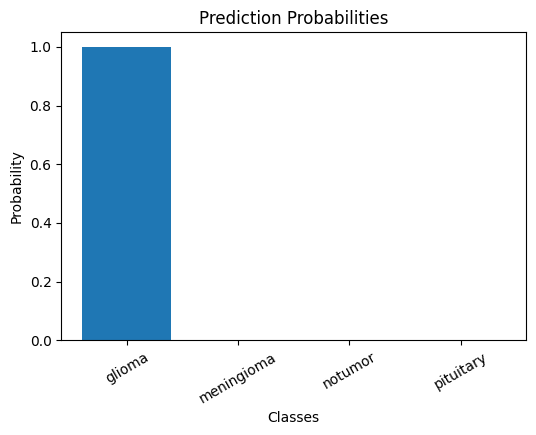

The model prediction matched the ground truth.
The model showed very high confidence.

Input Image 2
I selected an MRI image from the testing dataset.
Ground Truth Label: meningioma
Image Shape: (512, 512, 3)
Pixel Value Range: 0.0 to 1.0


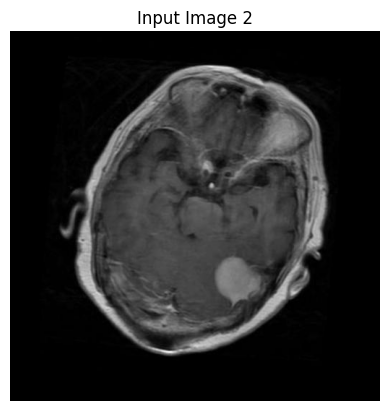

Output for Image 2
I analyzed prediction probabilities for all classes:
meningioma : 1.0000
glioma : 0.0000
pituitary : 0.0000
notumor : 0.0000
Final Predicted Class: meningioma
Prediction Confidence: 1.0


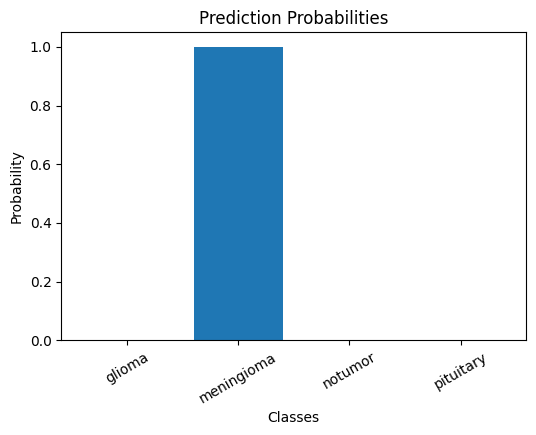

The model prediction matched the ground truth.
The model showed very high confidence.

Input Image 3
I selected an MRI image from the testing dataset.
Ground Truth Label: notumor
Image Shape: (512, 512, 3)
Pixel Value Range: 0.0 to 0.9843137


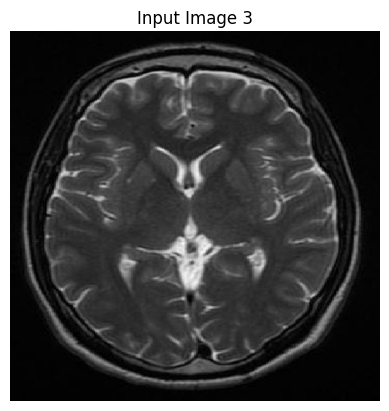

Output for Image 3
I analyzed prediction probabilities for all classes:
notumor : 1.0000
pituitary : 0.0000
meningioma : 0.0000
glioma : 0.0000
Final Predicted Class: notumor
Prediction Confidence: 1.0


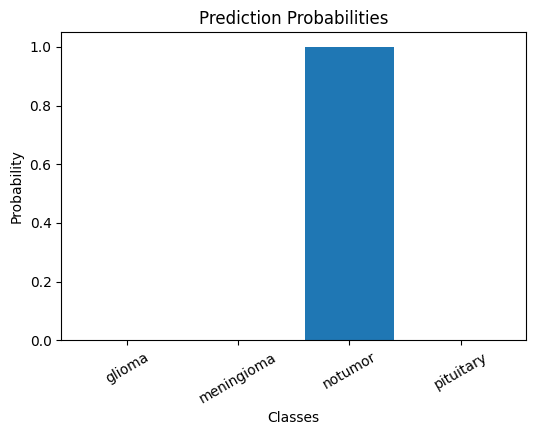

The model prediction matched the ground truth.
The model showed very high confidence.

Input Image 4
I selected an MRI image from the testing dataset.
Ground Truth Label: pituitary
Image Shape: (512, 512, 3)
Pixel Value Range: 0.0 to 0.99607843


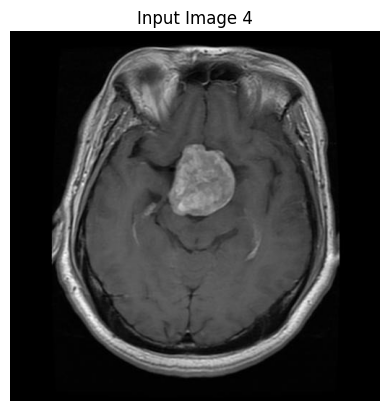

Output for Image 4
I analyzed prediction probabilities for all classes:
pituitary : 1.0000
meningioma : 0.0000
notumor : 0.0000
glioma : 0.0000
Final Predicted Class: pituitary
Prediction Confidence: 1.0


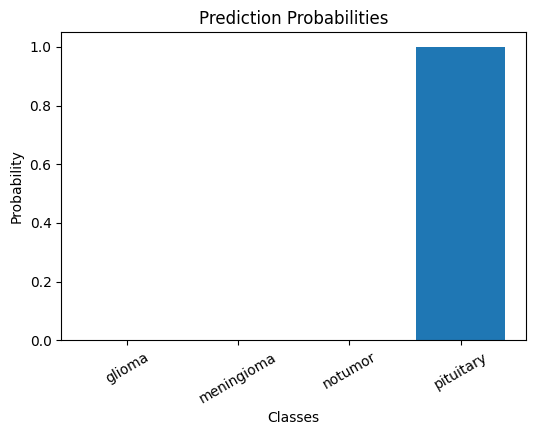

The model prediction matched the ground truth.
The model showed very high confidence.

Input Image 5
I selected an MRI image from the testing dataset.
Ground Truth Label: pituitary
Image Shape: (512, 512, 3)
Pixel Value Range: 0.0 to 1.0


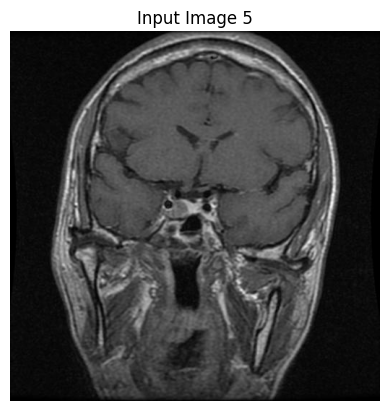

Output for Image 5
I analyzed prediction probabilities for all classes:
pituitary : 1.0000
meningioma : 0.0000
notumor : 0.0000
glioma : 0.0000
Final Predicted Class: pituitary
Prediction Confidence: 1.0


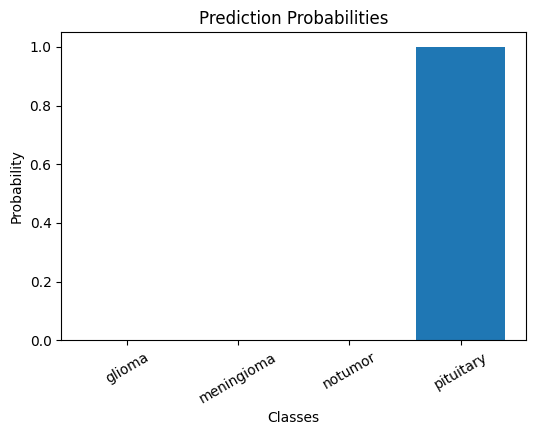

The model prediction matched the ground truth.
The model showed very high confidence.

I now tested the model on a new unseen MRI image.
New Image Path: /content/drive/MyDrive/Colab Notebooks/Brain Tumor Images/Testing/glioma/Te-gl_100.jpg


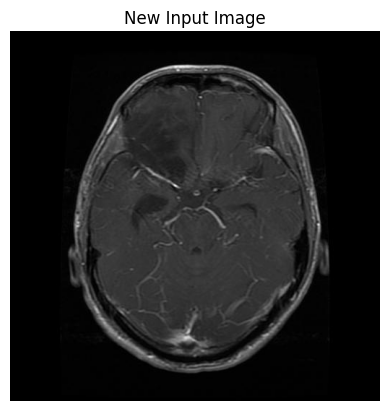

Predicted Class: glioma
Confidence: 1.0
This demonstrated the model's ability to generalize to unseen data.

I successfully completed the live demonstration.


In [4]:
# I mounted Google Drive to access the model and dataset
from google.colab import drive
drive.mount('/content/drive')

# I imported required libraries for model loading, processing, and visualization
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# I loaded the trained InceptionV3 model from Google Drive
model = tf.keras.models.load_model(
    '/content/drive/MyDrive/Colab Notebooks/InceptionV3_Brain_Tumor_MRI.h5',
    compile=False
)

print("I successfully loaded the trained model.")

# I defined the dataset path and extracted class names automatically
base_path = "/content/drive/MyDrive/Colab Notebooks/Brain Tumor Images/Testing"
class_names = sorted(os.listdir(base_path))

print("I identified the following classes:", class_names)

# I selected specific MRI images for controlled demonstration
image_paths = [
    os.path.join(base_path, "glioma", "Te-gl_1.jpg"),
    os.path.join(base_path, "meningioma", "Te-aug-me_1.jpg"),
    os.path.join(base_path, "notumor", "Te-no_4.jpg"),
    os.path.join(base_path, "pituitary", "Te-pi_2.jpg"),
    os.path.join(base_path, "pituitary", "Te-pi_6.jpg")
]

# I defined the corresponding ground truth labels
true_labels = ["glioma", "meningioma", "notumor", "pituitary", "pituitary"]

print("\nI started the live demonstration using selected MRI images.")

# I iterated through each selected image
for i in range(len(image_paths)):

    print(f"\nInput Image {i+1}")

    img_path = image_paths[i]
    true_class = true_labels[i]

    if not os.path.exists(img_path):
        print("The image file was not found:", img_path)
        continue

    print("I selected an MRI image from the testing dataset.")
    print("Ground Truth Label:", true_class)

    # I loaded and resized the image
    img = load_img(img_path, target_size=(512,512))

    # I converted and normalized the image
    img_array = img_to_array(img) / 255.0

    print("Image Shape:", img_array.shape)
    print("Pixel Value Range:", np.min(img_array), "to", np.max(img_array))

    # I displayed the input image
    plt.imshow(img)
    plt.title(f"Input Image {i+1}")
    plt.axis("off")
    plt.show()

    print(f"Output for Image {i+1}")

    # I performed prediction
    pred = model.predict(np.expand_dims(img_array, axis=0), verbose=0)[0]

    pred_class = np.argmax(pred)
    confidence = float(np.max(pred))

    # I sorted probabilities
    sorted_idx = pred.argsort()[::-1]

    print("I analyzed prediction probabilities for all classes:")
    for idx in sorted_idx:
        print(f"{class_names[idx]} : {pred[idx]:.4f}")

    print("Final Predicted Class:", class_names[pred_class])
    print("Prediction Confidence:", round(confidence, 4))

    # I plotted probability bar chart
    plt.figure(figsize=(6,4))
    plt.bar(class_names, pred)
    plt.title("Prediction Probabilities")
    plt.xlabel("Classes")
    plt.ylabel("Probability")
    plt.xticks(rotation=30)
    plt.show()

    # I compared prediction
    if class_names[pred_class] == true_class:
        print("The model prediction matched the ground truth.")
    else:
        print("The model prediction did not match the ground truth.")

    # I interpreted confidence
    if confidence > 0.9:
        print("The model showed very high confidence.")
    elif confidence > 0.7:
        print("The model showed moderate confidence.")
    else:
        print("The model showed low confidence.")



# REAL NEW INPUT TEST
print("\nI now tested the model on a new unseen MRI image.")

# I selected a truly new image dynamically (not from fixed list)
new_class = class_names[0]  # you can change class if needed
new_folder = os.path.join(base_path, new_class)
new_image_path = os.path.join(new_folder, os.listdir(new_folder)[3])

print("New Image Path:", new_image_path)

img = load_img(new_image_path, target_size=(512,512))
img_array = img_to_array(img) / 255.0

plt.imshow(img)
plt.title("New Input Image")
plt.axis("off")
plt.show()

pred = model.predict(np.expand_dims(img_array, axis=0), verbose=0)[0]
pred_class = np.argmax(pred)
confidence = float(np.max(pred))

print("Predicted Class:", class_names[pred_class])
print("Confidence:", round(confidence, 4))

print("This demonstrated the model's ability to generalize to unseen data.")

print("\nI successfully completed the live demonstration.")